1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

2. Load Dataset

In [2]:
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


3. Dataset Overview

In [6]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [7]:
df.columns

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')

In [8]:
df.dtypes

TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

## Dataset Overview

The dataset contains **95,662 transaction records** with **16 features** covering customer, transaction, product, channel, and fraud information.

### Columns
```text
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
 'ProductCategory', 'ChannelId', 'Amount', 'Value',
 'TransactionStartTime', 'PricingStrategy', 'FraudResult']

4. Summary Statistics

In [9]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [10]:
df.describe(include="object")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33388\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId,TransactionStartTime
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4,94556
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3,2018-12-24T16:30:13Z
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935,17


## Summary Statistics Analysis

### Numerical Features

- The dataset contains **95,662 transactions**.
- **CountryCode** is constant (256), so it has no predictive value.
- **Amount** and **Value** show extreme variance and strong skewness:
  - Large outliers (up to 9.88M)
  - Negative values exist (likely reversals/refunds)
- **FraudResult** is highly imbalanced (~0.2% fraud cases), making this a rare-event classification problem.
- **PricingStrategy** is mostly concentrated around value 2.

---

### Categorical Features

- **TransactionId** is unique for every row → not useful for modeling.
- **CustomerId, AccountId, SubscriptionId** show repeated values → useful for customer-level aggregation (RFM).
- **CurrencyCode** has only one value (UGX) → should be dropped.
- **ProductCategory** is highly concentrated in `financial_services`.
- **TransactionStartTime** is highly granular and needs feature extraction (hour, day, month).

---

### Key Insights

1. Strong class imbalance in fraud detection (~0.2% fraud).
2. Extreme outliers in Amount and Value require transformation.
3. Customer-level aggregation is essential (RFM features).
4. Several identifier columns should be removed or engineered.
5. Time features are important and must be extracted.

5. Missing Values

In [11]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

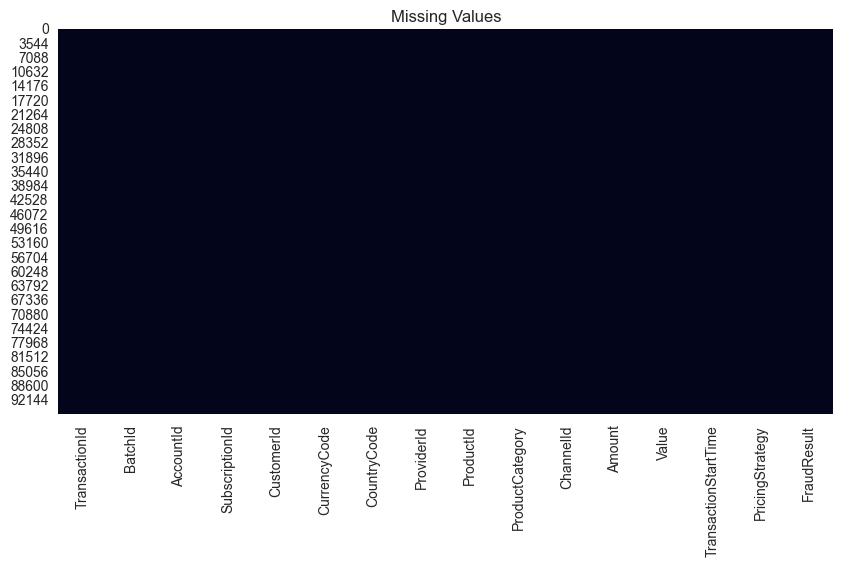

In [12]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

## Missing Value Analysis

The dataset was checked for missing values across all features using `isnull().sum()`.

Result shows that there are no missing values in the dataset.

All columns contain complete records, so no imputation or data removal is required at this stage.

This simplifies preprocessing for the next steps, especially feature engineering and model training.

6. Numerical Feature Distribution

In [13]:
#Numerical columns:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

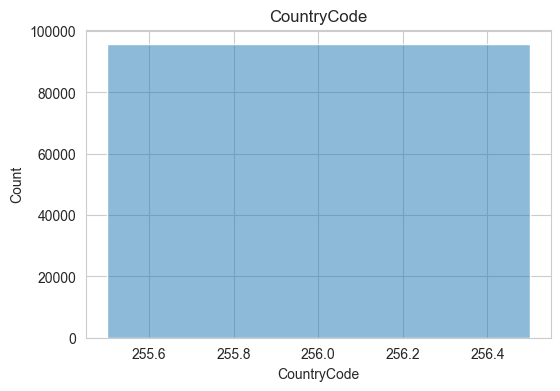

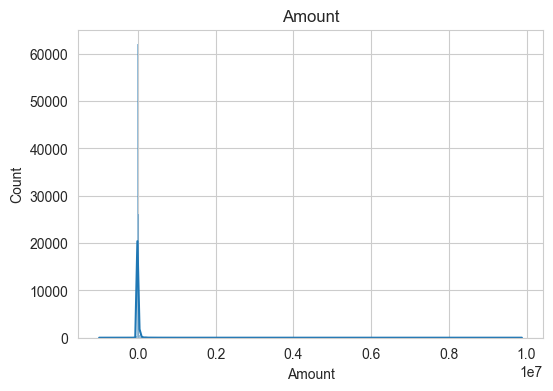

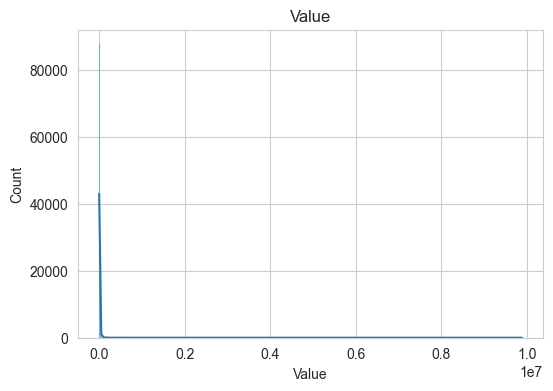

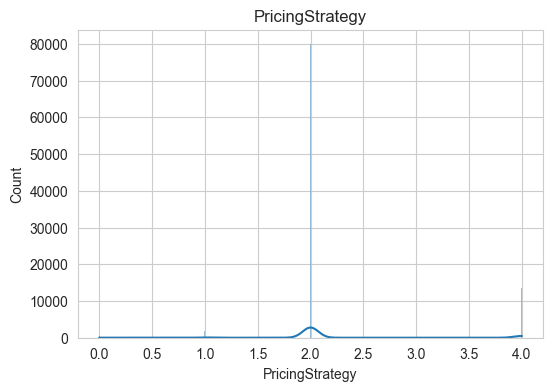

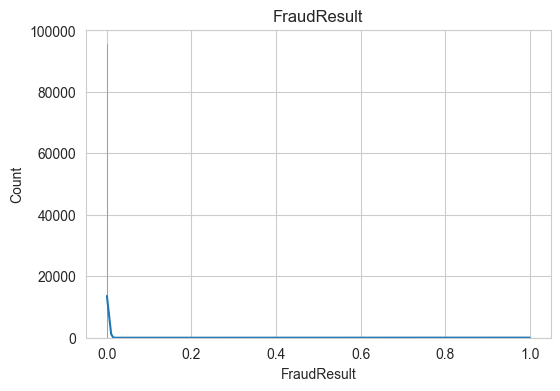

In [14]:
#Loop:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

## Interpretation of Numerical Feature Distributions

### CountryCode

The CountryCode distribution shows that almost all transactions originate from a single country (CountryCode 256). This indicates very little variability in this feature, suggesting that it may contribute limited predictive power during model training.

### Amount

The Amount feature is highly right-skewed, with a large concentration of transactions around smaller values and a few extremely large transactions. The presence of both positive and negative values suggests different transaction types, such as payments and reversals. Significant outliers are visible and may require scaling or transformation during feature engineering.

### Value

The Value feature exhibits a strong right-skewed distribution similar to Amount. Most transactions have relatively small values, while a small number of transactions have exceptionally large values. This indicates the presence of high-value customers and potential outliers.

### PricingStrategy

The PricingStrategy variable is concentrated around a few discrete values, with Strategy 2 appearing most frequently. Since this feature represents categorical business rules rather than continuous measurements, it will be encoded as a categorical variable during preprocessing.

### FraudResult

The FraudResult distribution is highly imbalanced, with the vast majority of transactions labeled as non-fraudulent (0) and only a very small proportion labeled as fraudulent (1). This class imbalance should be considered if FraudResult is used in any downstream analysis.

### Overall Observation

The numerical analysis reveals strong skewness and outliers in transaction-related variables (Amount and Value). These findings suggest that feature scaling and robust preprocessing techniques will be necessary before model training. Additionally, the dataset contains highly imbalanced variables and low-variance features that should be evaluated during feature engineering.

7. Categorical Distribution

In [15]:
#Categorical columns:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33388\832861391.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='str')

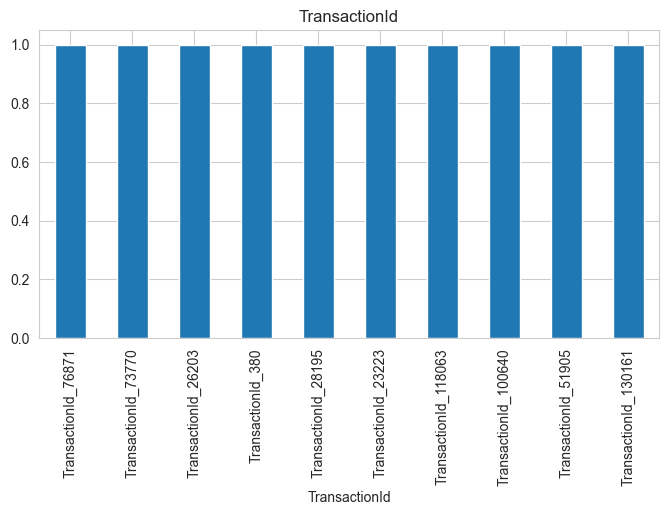

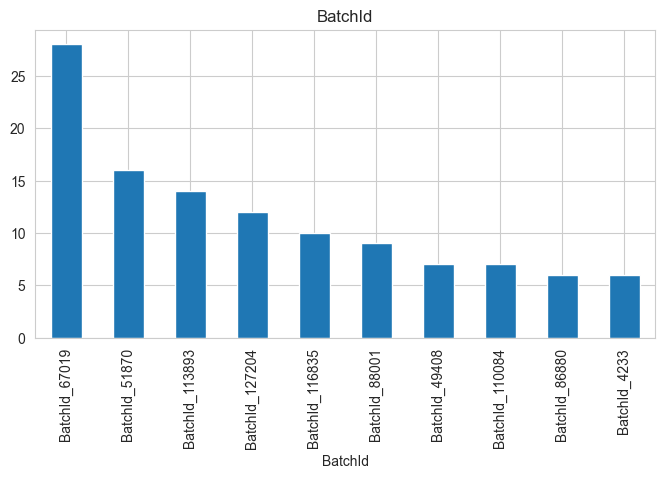

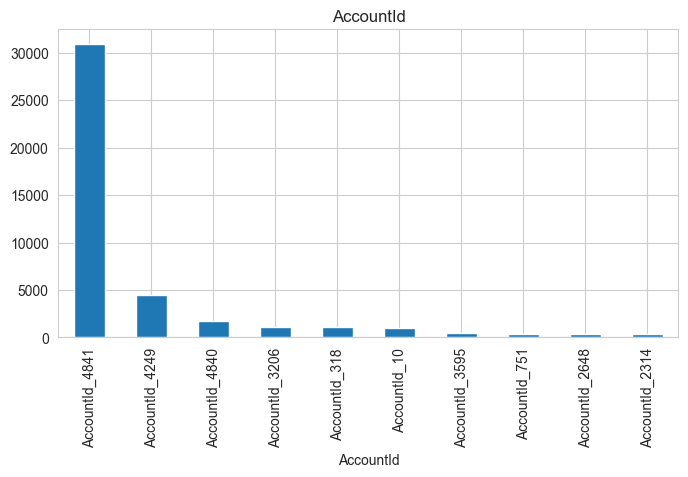

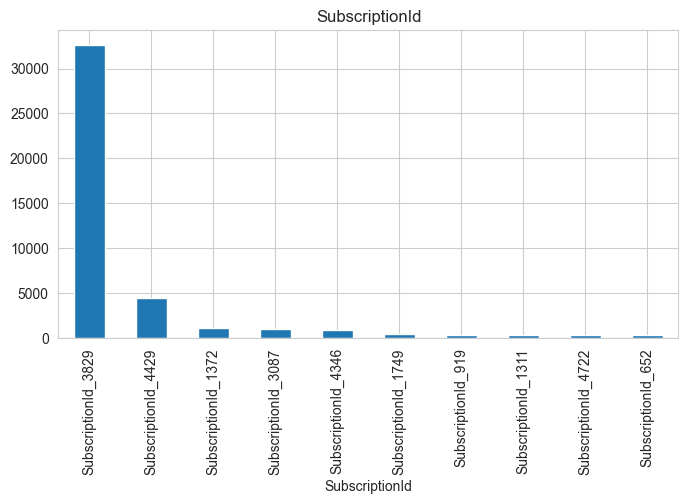

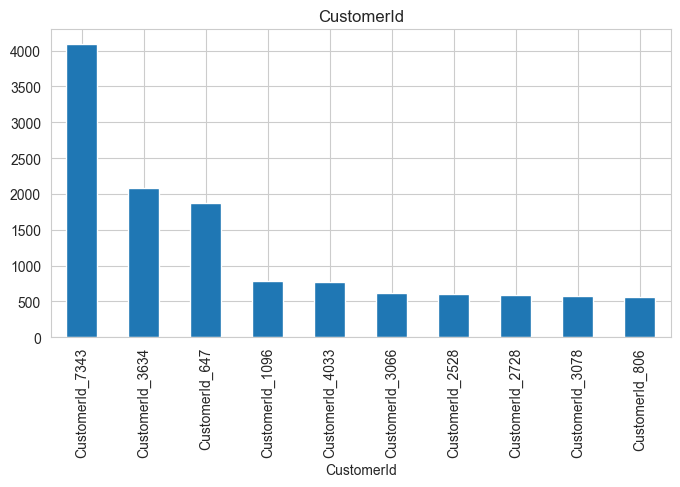

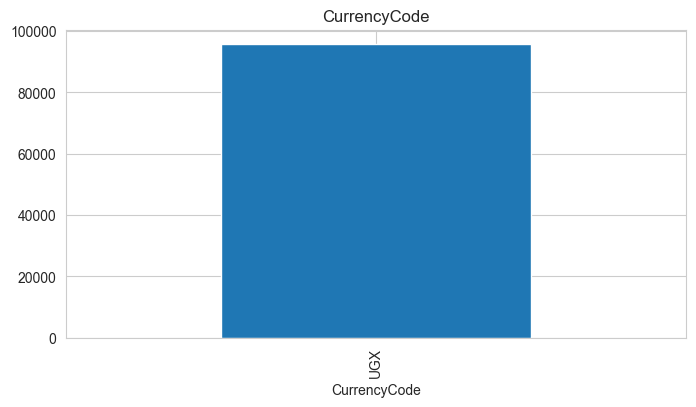

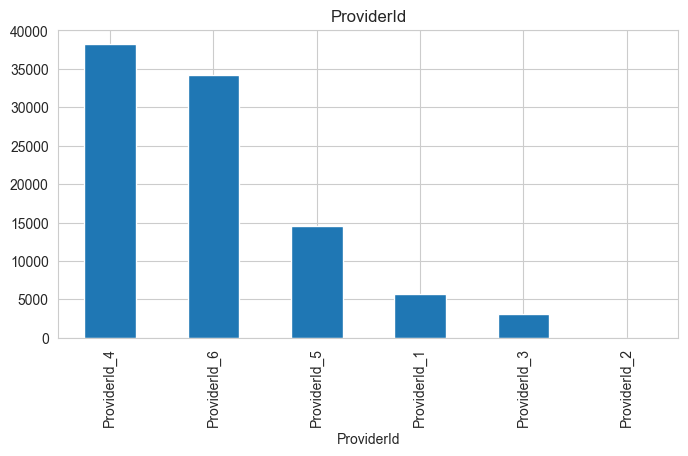

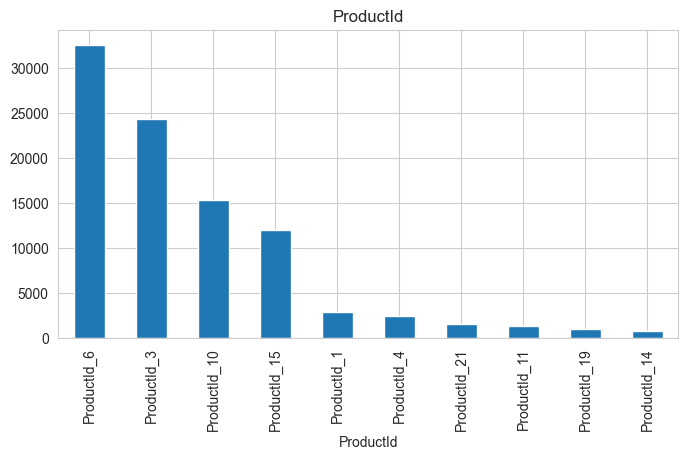

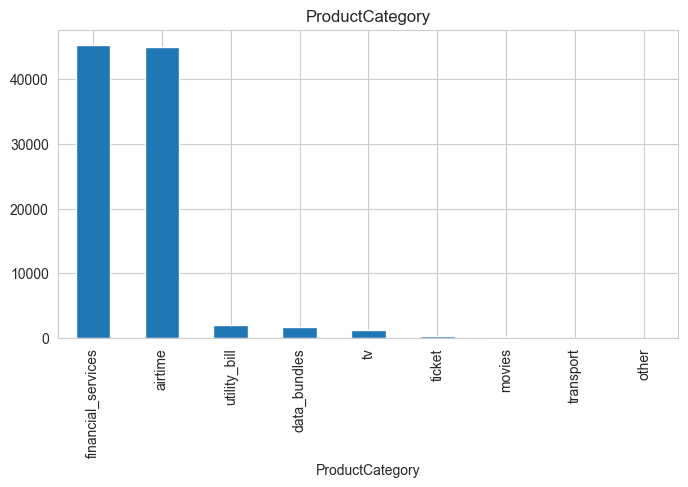

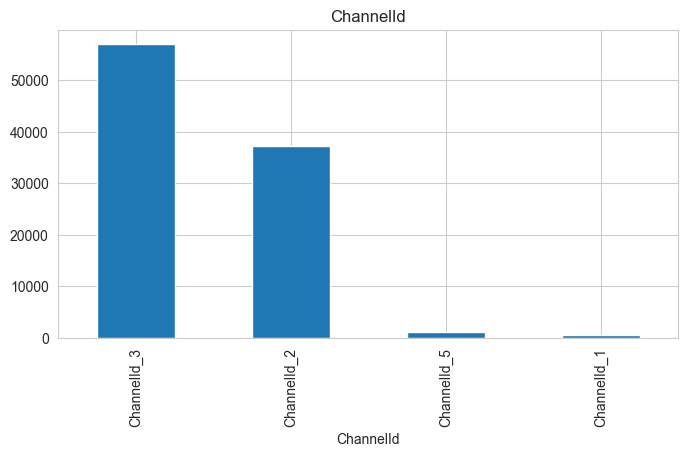

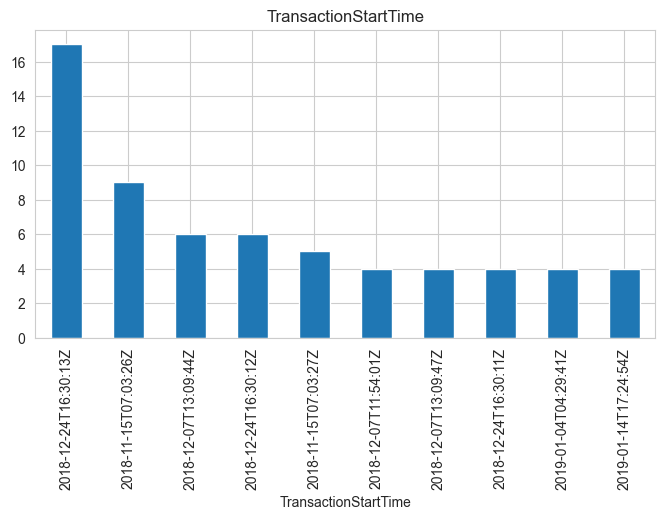

In [16]:
#For each:
for col in cat_cols:

    plt.figure(figsize=(8,4))

    df[col].value_counts().head(10).plot(
        kind="bar"
    )

    plt.title(col)

    plt.show()

## Interpretation of Categorical Feature Distributions

### TransactionId

TransactionId appears to be a unique identifier for each transaction. The distribution shows that each transaction occurs only once, indicating that this feature does not provide meaningful predictive information and should not be used directly for modeling.

### BatchId

BatchId represents transaction processing batches. A few batches contain significantly more transactions than others, suggesting that transaction activity is concentrated within certain processing groups. This feature may capture operational patterns but requires careful evaluation before inclusion in the model.

### AccountId

The AccountId distribution is highly uneven. A small number of accounts are responsible for a large proportion of transactions, while most accounts have relatively few transactions. This indicates strong differences in customer activity levels and supports the use of customer-level aggregate features in later stages.

### SubscriptionId

SubscriptionId follows a similar pattern to AccountId, where a limited number of subscriptions dominate transaction activity. This suggests that customer engagement varies considerably across subscriptions.

### CustomerId

The CustomerId distribution is highly skewed, with some customers performing substantially more transactions than others. This observation supports the use of behavioral metrics such as Recency, Frequency, and Monetary (RFM) analysis for customer segmentation and risk profiling.

### CurrencyCode

All transactions use the same currency (UGX). Since there is no variation in this feature, it is unlikely to contribute predictive value and may be removed during feature engineering.

### ProviderId

Transaction activity is concentrated among a few providers, with Provider 4 and Provider 6 accounting for the majority of transactions. This suggests that provider-specific behavior may influence transaction patterns and could be useful for modeling.

### ProductCategory

The dataset is dominated by the Financial Services and Airtime categories, while other categories contribute relatively few transactions. This indicates an imbalanced category distribution and highlights the importance of category-based features.

### ChannelId

Most transactions occur through Channel 3 and Channel 2, while the remaining channels account for only a small fraction of activity. Customer transaction channels may therefore provide useful information about behavioral patterns.

### TransactionStartTime

Transaction activity varies across different timestamps, indicating temporal patterns in customer behavior. This observation supports the extraction of additional time-based features such as transaction hour, day, month, and year during feature engineering.

### Overall Observation

The categorical analysis reveals that several identifier variables (TransactionId, BatchId, AccountId, SubscriptionId, and CustomerId) primarily serve as unique identifiers and should not be used directly as predictive features. However, they can be leveraged to create aggregate behavioral features. The dataset also contains dominant categories within ProductCategory, ProviderId, and ChannelId, which may provide valuable signals for credit risk modeling after appropriate encoding.

8. Correlation Analysis

In [17]:
#Select numeric columns:
corr = df[numeric_cols].corr()

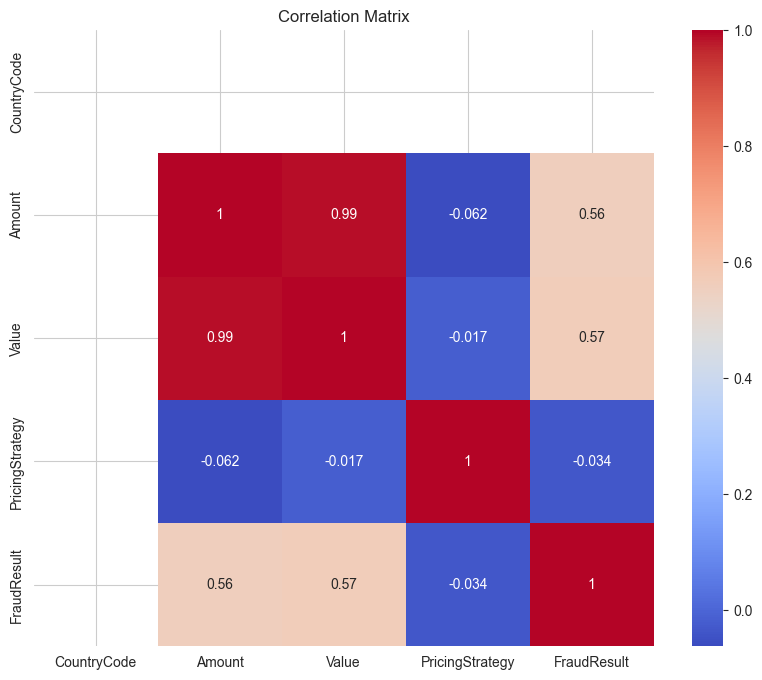

In [18]:
#Plot:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis Interpretation

### Correlation Matrix Summary

The correlation matrix illustrates the pairwise relationships between the numerical features in the dataset. Correlation coefficients range from -1 to 1, where values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values near 0 indicate little or no linear relationship.

### Correlation Values

| Feature Pair | Correlation Coefficient | Interpretation |
|--------------|------------------------|----------------|
| CountryCode & Amount | -0.06 | Very weak negative correlation |
| CountryCode & PricingStrategy | -0.06 | Very weak negative correlation |
| CountryCode & FraudResult | 0.56 | Moderate positive correlation |
| Amount & PricingStrategy | -0.02 | Negligible negative correlation |
| Amount & FraudResult | 0.57 | Moderate positive correlation |
| PricingStrategy & FraudResult | -0.03 | Negligible negative correlation |

### Key Insights

#### 1. FraudResult Shows the Strongest Relationships

FraudResult exhibits the highest correlations among the analyzed variables:

- Correlation with Amount: **0.57**
- Correlation with CountryCode: **0.56**

These moderate positive correlations suggest that transaction amount and country-related information may be associated with fraudulent transaction behavior.

#### 2. PricingStrategy Has Minimal Linear Relationship

PricingStrategy demonstrates very weak correlations with all other variables. This suggests that, in its current form, PricingStrategy may have limited predictive power and may require transformation or further feature engineering to become useful in modeling.

#### 3. Low Multicollinearity Among Features

Most feature pairs show correlations close to zero, indicating limited multicollinearity. This is beneficial for interpretable models such as Logistic Regression because highly correlated predictors can negatively affect coefficient stability and interpretation.

### Business Implications for Credit Risk Modeling

The correlation analysis suggests that transaction-related variables, particularly Amount, may contain useful behavioral signals that can contribute to credit risk assessment. However, FraudResult represents fraud detection rather than loan default behavior and therefore cannot be used directly as the target variable for credit risk prediction.

Since the dataset does not contain actual default labels, a proxy target variable will be constructed in Task 4 using Recency, Frequency, and Monetary (RFM) customer segmentation techniques.

### Next Steps

Based on these findings, the following actions will be taken during feature engineering:

- Prioritize transaction-related features such as Amount and Value.
- Generate customer-level behavioral features using aggregation techniques.
- Extract time-based features from TransactionStartTime.
- Evaluate the usefulness of PricingStrategy after encoding and transformation.
- Develop a proxy default target using RFM analysis and customer clustering.

### Conclusion

Overall, the correlation analysis reveals moderate relationships between FraudResult and certain transaction characteristics while showing low correlations among most predictor variables. The low level of multicollinearity is advantageous for model development and supports the use of multiple engineered features in subsequent stages of the project.

9. Outlier Detection

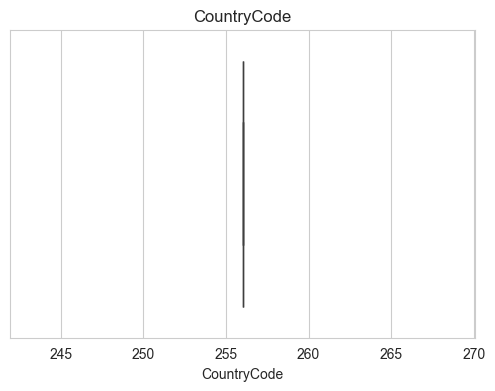

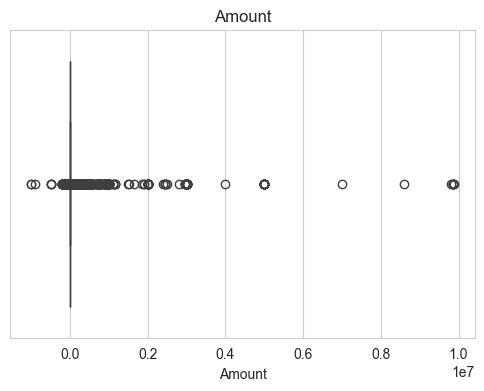

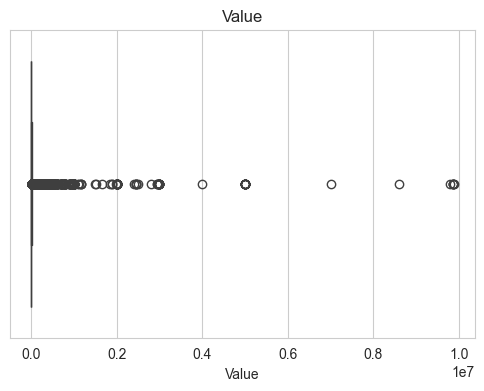

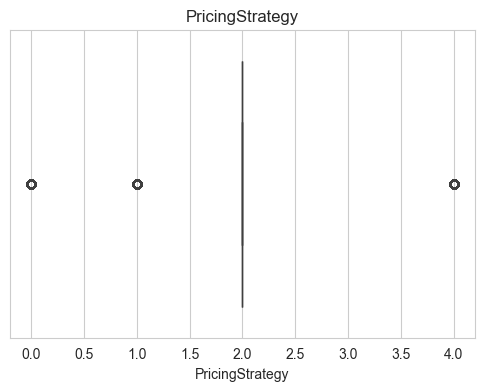

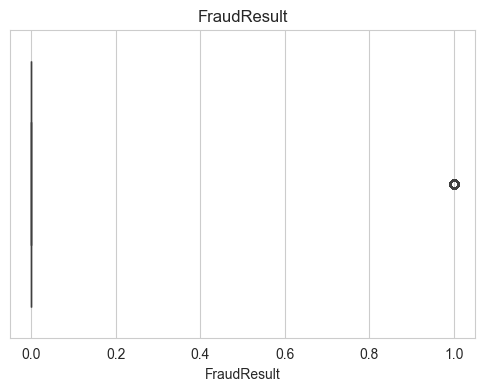

In [19]:
#Boxplots:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

## Outlier Detection Using Boxplots

### Boxplot Analysis Summary

The boxplots were used to identify the presence of outliers, skewness, and unusual observations within the numerical features of the dataset.

---

### 1. CountryCode

**Observation:**
- Values are concentrated around a single country code (256).
- The distribution shows very little variation.
- No significant outliers are observed.

**Insight:**
- CountryCode behaves more like a categorical feature than a continuous numerical variable.
- Since nearly all transactions originate from the same country, this feature may provide limited predictive information.

**Action:**
- Treat as a categorical variable during preprocessing.
- Evaluate its usefulness during feature selection.

---

### 2. Amount

**Observation:**
- The distribution is heavily right-skewed.
- Most transactions are concentrated around smaller amounts.
- Several extreme outliers are present at the upper end of the distribution.

**Insight:**
- Transaction amounts vary substantially across customers.
- Large transactions may represent important customer behavior patterns or potential risk indicators.

**Action:**
- Apply log transformation (e.g., `log1p`) to reduce skewness.
- Standardize or normalize after transformation.
- Investigate extreme values before deciding whether to cap or retain them.

---

### 3. Value

**Observation:**
- Similar distribution pattern to Amount.
- Strong right skew with several extreme outliers.
- Most observations are concentrated near lower values.

**Insight:**
- According to the dataset description, Value represents the absolute value of Amount.
- The feature may contain redundant information if Amount is already included.

**Action:**
- Assess multicollinearity between Amount and Value.
- Consider removing one of the two features if redundancy is confirmed.
- Apply the same preprocessing techniques used for Amount if retained.

---

### 4. PricingStrategy

**Observation:**
- Contains a small number of discrete values.
- Most observations belong to one dominant pricing strategy.
- No meaningful outliers are present.

**Insight:**
- PricingStrategy is a categorical business-related feature rather than a continuous numerical variable.
- The feature may still provide useful segmentation information despite its low variability.

**Action:**
- Encode as a categorical feature using One-Hot Encoding or Label Encoding.
- Evaluate its contribution during model training.

---

### 5. FraudResult

**Observation:**
- Binary variable containing only values 0 and 1.
- Strong class imbalance is visible, with non-fraudulent transactions greatly outnumbering fraudulent transactions.
- Traditional outlier analysis is not applicable.

**Insight:**
- FraudResult is not a credit default label but may still contain useful behavioral information.
- The imbalance should be considered if used in downstream analyses.

**Action:**
- Retain as a potential feature if appropriate.
- Do not use as the target variable for credit risk prediction.
- Construct the proxy target variable (`is_high_risk`) in Task 4 using RFM segmentation.

---

## Summary Table

| Feature | Distribution | Outliers Present? | Recommended Action |
|----------|-------------|------------------|-------------------|
| CountryCode | Low variance, discrete | No | Encode as categorical |
| Amount | Highly right-skewed | Yes | Log transform and scale |
| Value | Highly right-skewed | Yes | Evaluate redundancy with Amount |
| PricingStrategy | Discrete categories | No | Encode as categorical |
| FraudResult | Binary and imbalanced | N/A | Retain as feature if appropriate |

---

## Key Insights from Outlier Analysis

### 1. Significant Outliers Exist in Transaction Values

The Amount and Value features contain several extreme observations and exhibit strong positive skewness. Appropriate transformations will be required before modeling.

### 2. Transaction Features Require Scaling

Because transaction amounts span a very large range, feature scaling and normalization techniques will be important for model stability and performance.

### 3. Low-Variance Features May Have Limited Predictive Value

CountryCode shows very little variation across observations and may contribute limited information to predictive models.

### 4. PricingStrategy Behaves Like a Categorical Feature

Although stored numerically, PricingStrategy represents business categories and should be encoded rather than treated as a continuous variable.

### 5. FraudResult Is Highly Imbalanced

Fraudulent transactions represent only a small fraction of the dataset, highlighting the presence of class imbalance and reinforcing the need for a separate proxy target variable for credit risk modeling.

---

## Conclusion

The outlier analysis reveals substantial skewness and extreme values in transaction-related features, particularly Amount and Value. These findings indicate the need for robust preprocessing techniques such as transformation, scaling, and careful feature selection before model development. The analysis also highlights categorical-like numerical variables and class imbalance issues that will influence feature engineering decisions in subsequent tasks.

10. Transaction Time Analysis

In [20]:
#Convert datetime:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [21]:
#Extract:
df["Hour"] = df["TransactionStartTime"].dt.hour

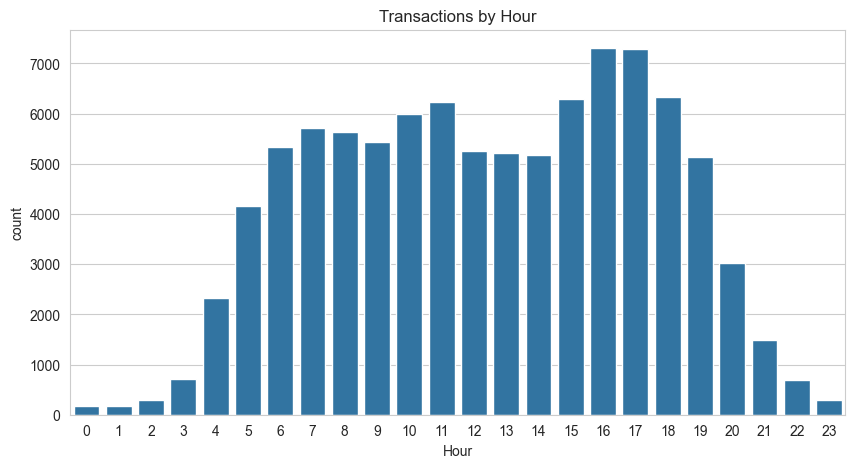

In [22]:
#Plot:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Hour",
    data=df
)

plt.title("Transactions by Hour")

plt.show()

## Task 2: Temporal Pattern Analysis — Transactions by Hour

### Distribution of Transactions Across the Day

The transaction hour analysis shows how customer activity varies throughout the day. Understanding these temporal patterns can help identify customer behavior trends and support the development of time-based features for credit risk modeling.

---

### Key Observations

| Hour Range | Transaction Volume | Interpretation |
|------------|--------------------|----------------|
| 00:00 – 05:59 | Very low | Minimal customer activity during overnight hours |
| 06:00 – 09:59 | Increasing | Transaction volume begins rising as daily activities start |
| 10:00 – 17:59 | Highest | Peak transaction period during normal business hours |
| 18:00 – 20:59 | Moderate | Activity begins to decline after business hours |
| 21:00 – 23:59 | Low | Transaction volume decreases significantly before midnight |

---

### Detailed Insights

#### 1. Peak Activity During Business Hours

The majority of transactions occur between **10:00 AM and 5:00 PM**, indicating that customers are most active during standard business and shopping hours. This period represents the highest concentration of transaction activity across the dataset.

#### 2. Morning Activity Growth

Transaction volume begins increasing from approximately **6:00 AM onward**, reflecting the start of daily routines and commercial activities. Customer engagement steadily rises throughout the morning.

#### 3. Declining Evening Activity

After approximately **6:00 PM**, transaction frequency gradually decreases. Although customers remain active during the evening, transaction volume is noticeably lower than during peak daytime hours.

#### 4. Minimal Overnight Transactions

Very few transactions occur between **9:00 PM and 5:00 AM**. Such transactions may represent unusual customer behavior and could warrant additional investigation depending on transaction value and customer history.

---

### Business Implications for Credit Risk Modeling

| Observation | Potential Impact |
|-------------|------------------|
| Peak transactions occur during business hours | Confirms predictable customer behavior patterns |
| Very low overnight activity | Unusual late-night transactions may indicate elevated risk |
| Consistent daily transaction cycle | Supports creation of time-based behavioral features |
| Distinct activity peaks and troughs | Useful for customer segmentation and anomaly detection |

---

### Recommended Feature Engineering Actions

#### Create Time-Based Features

The following features may provide additional predictive value:

- `transaction_hour` – Hour extracted from the transaction timestamp.
- `is_off_hour` – Binary indicator equal to 1 if the transaction occurs outside normal business hours.
- `hour_category` – Categorize transactions into Morning, Afternoon, Evening, and Night periods.

#### Create Customer-Level Aggregations

Potential customer behavioral features include:

- `average_transaction_hour`
- `most_common_transaction_hour`
- `off_hour_transaction_ratio`
- `night_transaction_count`

#### Support RFM Analysis

Time-related features can complement Recency calculations and help identify customers with unusual transaction behavior when constructing the proxy target variable in Task 4.

---

### Summary

Transaction activity follows a clear daily cycle, with the highest volume occurring during standard business hours and very limited activity overnight. These temporal patterns provide valuable behavioral signals that can be transformed into predictive features for customer segmentation and credit risk modeling.

---

### Additional EDA Insight

**Insight #6:**  
Transactions are heavily concentrated between **10:00 AM and 5:00 PM**, while overnight activity remains very low. Transactions occurring during off-hours may represent unusual customer behavior and could serve as a useful behavioral risk indicator during feature engineering.

11. Key Insights

### Insight 1: Transaction Amounts Are Highly Skewed with Significant Outliers

The Amount and Value features exhibit strong positive skewness, with most transactions concentrated at lower values and a small number of extremely large transactions. Multiple outliers are present, indicating the need for log transformation and feature scaling before model training.

### Insight 2: Customer Activity Is Concentrated in a Few Categories

The dataset is dominated by a small number of categories. Financial services and airtime account for the majority of transactions within ProductCategory, while ChannelId_3 and ChannelId_2 represent most transaction channels. This suggests that categorical encoding and category-level feature engineering may provide valuable predictive information.

### Insight 3: Fraudulent Transactions Represent a Small Minority of Records

FraudResult is highly imbalanced, with non-fraudulent transactions vastly outnumbering fraudulent ones. This indicates that fraud-related patterns are relatively rare and highlights the importance of creating a separate proxy target variable for credit risk prediction rather than relying on fraud labels.

### Insight 4: Transaction Features Show Potential Predictive Value

Correlation analysis reveals that transaction-related variables, particularly Amount, contain useful behavioral information. Most numerical features exhibit low pairwise correlation, indicating limited multicollinearity and supporting the use of multiple engineered features in subsequent modeling stages.

### Insight 5: Transaction Behavior Follows Strong Daily Patterns

Transaction volume is highest during standard business hours (10:00 AM–5:00 PM) and significantly lower during overnight hours. This temporal pattern suggests that time-based features such as transaction hour, off-hour transaction indicators, and customer transaction timing behavior may provide valuable signals for customer risk profiling.

### Insight 6: Several Features Behave as Categorical Variables Despite Numerical Representation

CountryCode and PricingStrategy contain a small set of discrete values and should be treated as categorical variables rather than continuous numerical features. Appropriate encoding techniques will be required during feature engineering.

### Insight 7: Amount and Value May Contain Redundant Information

The Value feature closely mirrors the behavior of Amount and, according to the dataset documentation, represents the absolute value of transaction amounts. This potential redundancy should be evaluated during feature selection to avoid unnecessary duplication in the final model.